# Walk-Forward Analysis — Sector Momentum (2018–2024)

A single backtest on 2010–2024 tells you how a strategy *would have* performed with parameters chosen in hindsight. Walk-forward tests whether those parameters generalise: pick params using only past data (in-sample), trade the next period you never saw (out-of-sample), roll forward. The gap between IS and OOS Sharpe reveals how much of the backtest edge was overfitting.

In [1]:
import os, sys

_cwd = os.getcwd()
_root = _cwd if os.path.exists(os.path.join(_cwd, "pyproject.toml")) \
    else os.path.abspath(os.path.join(_cwd, ".."))
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
os.makedirs("results", exist_ok=True)

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from backtest_engine.data.loader import load_prices
from backtest_engine.strategies.momentum import momentum_signals
from backtest_engine.backtest.walk_forward import walk_forward_test
from backtest_engine.metrics.performance import (
    sharpe_ratio, cagr, max_drawdown, calmar_ratio,
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

SECTOR_ETFS = ["XLK", "XLF", "XLV", "XLE", "XLY",
               "XLP", "XLI", "XLB", "XLU", "XLRE", "XLC"]
START        = "2010-01-01"
END          = "2024-12-31"
TRAIN_YEARS  = 3
TEST_YEARS   = 1

## 1. Load Data

Same universe as notebook 02. Effective start is 2018-06-19 (XLC constraint).

In [2]:
prices = load_prices(SECTOR_ETFS, START, END, cache=True)
print(f"Loaded {len(prices)} trading days: "
      f"{prices.index[0].date()} → {prices.index[-1].date()}")
span_years = (prices.index[-1] - prices.index[0]).days / 365
n_windows = int(span_years - TRAIN_YEARS) // TEST_YEARS
print(f"Span: {span_years:.1f} yr  |  "
      f"Expected windows (train={TRAIN_YEARS}y / test={TEST_YEARS}y): ~{n_windows}")

Loaded 1644 trading days: 2018-06-19 → 2024-12-30
Span: 6.5 yr  |  Expected windows (train=3y / test=1y): ~3


## 2. Walk-Forward Run

**Parameter grid:** 3 lookback lengths × 3 portfolio sizes = 9 combinations.  
For each training window, every combination is backtested and the winner (best Sharpe ratio) is carried forward into the out-of-sample test period.

In [3]:
def strategy_fn(prices_slice: pd.DataFrame, **kwargs) -> pd.DataFrame:
    """Thin wrapper — fixes skip_months=1 (12-1 J&T convention)."""
    return momentum_signals(prices_slice, skip_months=1, **kwargs)

param_grid = {
    "lookback_months": [6, 9, 12],
    "top_n":           [2, 3, 5],
}

n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)
print(f"Running walk-forward: {TRAIN_YEARS}y train / {TEST_YEARS}y test")
print(f"Parameter grid: {param_grid}  ({n_combos} combinations)\n")

wf = walk_forward_test(
    prices,
    strategy_fn,
    param_grid,
    train_years=TRAIN_YEARS,
    test_years=TEST_YEARS,
    metric="sharpe_ratio",
    transaction_cost_bps=5,
    slippage_bps=2,
)

print(f"Windows completed : {len(wf.windows)}")
print(f"OOS period        : {wf.oos_returns.index[0].date()} → "
      f"{wf.oos_returns.index[-1].date()}")
print(f"OOS trading days  : {len(wf.oos_returns)}")

Running walk-forward: 3y train / 1y test
Parameter grid: {'lookback_months': [6, 9, 12], 'top_n': [2, 3, 5]}  (9 combinations)

Windows completed : 3
OOS period        : 2021-06-21 → 2024-06-18
OOS trading days  : 754


## 3. Window-by-Window Results

In [4]:
sep = "─" * 92
print("\nWalk-Forward Window Summary")
print(sep)
print(f"  {'Win':<4} {'Training window':<27} {'Test window':<27} "
      f"{'Best params':<26} {'IS Sharpe':>9} {'OOS Sharpe':>10}")
print(sep)
for i, w in enumerate(wf.windows, 1):
    params_str = "  ".join(f"{k}={v}" for k, v in w.best_params.items())
    print(
        f"  {i:<4} "
        f"{w.train_start.date()} → {w.train_end.date()}  "
        f"{w.test_start.date()} → {w.test_end.date()}  "
        f"{params_str:<26} "
        f"{w.is_metric:>9.3f} "
        f"{w.oos_metric:>10.3f}"
    )
print(sep)
print(f"  {'AVG':<4} {'':27} {'':27} {'':26} {wf.avg_is_metric:>9.3f} {'':>10}")
print(f"  {'OOS':<4} {'':27} {'':27} {'':26} {'':>9} {wf.oos_metric:>10.3f}")
print()


Walk-Forward Window Summary
────────────────────────────────────────────────────────────────────────────────────────────
  Win  Training window             Test window                 Best params                IS Sharpe OOS Sharpe
────────────────────────────────────────────────────────────────────────────────────────────
  1    2018-06-19 → 2021-06-19  2021-06-19 → 2022-06-19  lookback_months=6  top_n=5     0.946     -0.622
  2    2019-06-19 → 2022-06-19  2022-06-19 → 2023-06-19  lookback_months=12  top_n=2     0.676      0.524
  3    2020-06-19 → 2023-06-19  2023-06-19 → 2024-06-19  lookback_months=6  top_n=2     0.960      1.266
────────────────────────────────────────────────────────────────────────────────────────────
  AVG                                                                                         0.861           
  OOS                                                                                                    0.343



## 4. IS vs OOS Sharpe Comparison

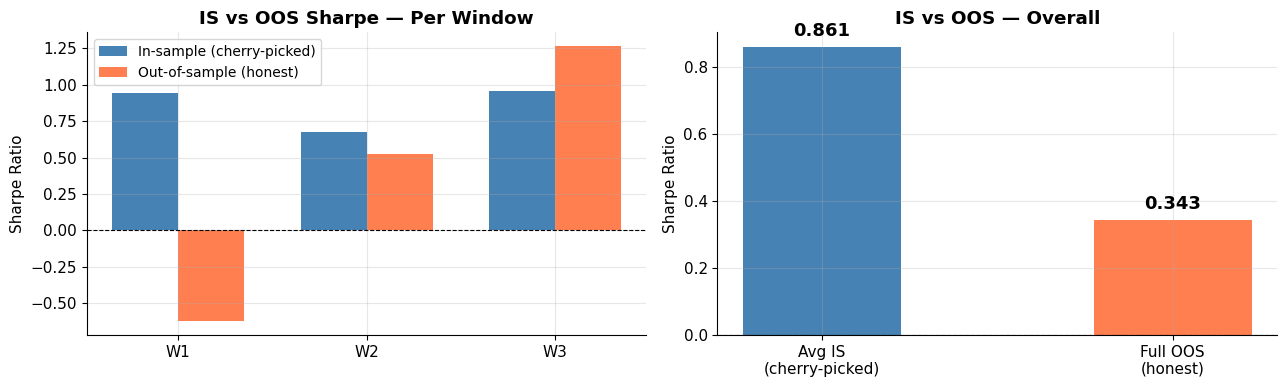

Saved → results/walk_forward_is_oos.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: per-window bars ──────────────────────────────────────────────────
ax = axes[0]
x = list(range(len(wf.windows)))
labels = [f"W{i+1}" for i in x]
is_vals  = [w.is_metric  for w in wf.windows]
oos_vals = [w.oos_metric for w in wf.windows]
w_bar = 0.35
ax.bar([xi - w_bar/2 for xi in x], is_vals,  w_bar,
       color="steelblue", label="In-sample (cherry-picked)")
ax.bar([xi + w_bar/2 for xi in x], oos_vals, w_bar,
       color="coral",     label="Out-of-sample (honest)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Sharpe Ratio")
ax.set_title("IS vs OOS Sharpe — Per Window", fontweight="bold")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.legend(fontsize=10)

# ── Right: summary ─────────────────────────────────────────────────────────
ax2 = axes[1]
summary_vals  = [wf.avg_is_metric, wf.oos_metric]
summary_labels = ["Avg IS\n(cherry-picked)", "Full OOS\n(honest)"]
bars = ax2.bar(summary_labels, summary_vals, color=["steelblue", "coral"], width=0.45)
for bar, val in zip(bars, summary_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", va="bottom",
             fontweight="bold", fontsize=13)
ax2.set_ylabel("Sharpe Ratio")
ax2.set_title("IS vs OOS — Overall", fontweight="bold")
ax2.axhline(0, color="black", lw=0.8, ls="--")

plt.tight_layout()
plt.savefig("results/walk_forward_is_oos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/walk_forward_is_oos.png")

## 5. OOS Equity Curve

Each shaded band shows one test window; the params selected in the preceding training window drive performance inside that band.

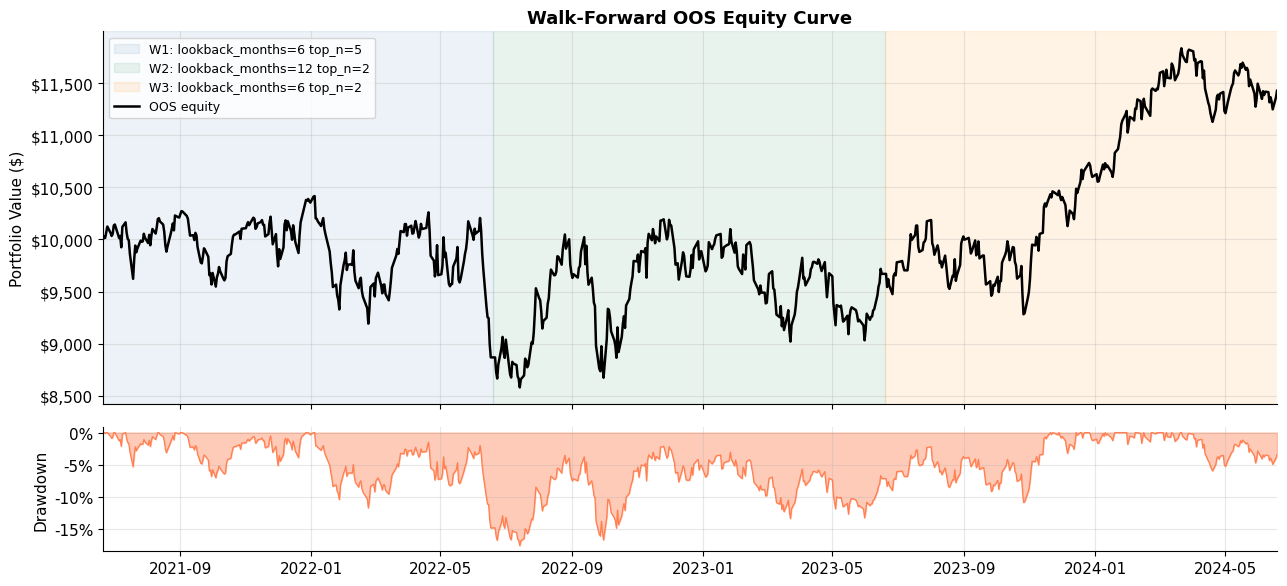

Saved → results/walk_forward_equity.png


In [6]:
oos_equity = (1.0 + wf.oos_returns).cumprod() * 10_000

fig, axes = plt.subplots(2, 1, figsize=(13, 6),
                          gridspec_kw={"height_ratios": [3, 1]},
                          sharex=True)

ax = axes[0]
band_colors = ["steelblue", "seagreen", "darkorange", "mediumpurple"]
for i, w in enumerate(wf.windows):
    params_str = " ".join(f"{k}={v}" for k, v in w.best_params.items())
    ax.axvspan(w.test_start, w.test_end,
               alpha=0.10, color=band_colors[i % len(band_colors)],
               label=f"W{i+1}: {params_str}")
ax.plot(oos_equity.index, oos_equity, lw=1.8, color="black", label="OOS equity")
ax.set_title("Walk-Forward OOS Equity Curve", fontweight="bold", fontsize=13)
ax.set_ylabel("Portfolio Value ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=9, loc="upper left")

ax2 = axes[1]
dd = oos_equity / oos_equity.cummax() - 1.0
ax2.fill_between(dd.index, dd, 0, color="coral", alpha=0.4)
ax2.plot(dd.index, dd, color="coral", lw=0.9)
ax2.set_ylabel("Drawdown")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.set_xlim(oos_equity.index[0], oos_equity.index[-1])

plt.tight_layout()
plt.savefig("results/walk_forward_equity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/walk_forward_equity.png")

## 6. Verdict Numbers

In [7]:
oos_cagr    = cagr(wf.oos_returns)
oos_sharpe  = sharpe_ratio(wf.oos_returns)
oos_mdd     = max_drawdown(wf.oos_returns)
oos_calmar  = calmar_ratio(wf.oos_returns)
gap         = wf.avg_is_metric - wf.oos_metric

print("═" * 58)
print("  WALK-FORWARD VERDICT")
print("═" * 58)
print(f"  Avg IS  Sharpe  (cherry-picked) : {wf.avg_is_metric:>+.3f}")
print(f"  Full OOS Sharpe (honest)        : {wf.oos_metric:>+.3f}")
print(f"  IS → OOS degradation            : {gap:>+.3f}")
print()
print(f"  OOS CAGR       : {oos_cagr:>+.1%}")
print(f"  OOS Sharpe     : {oos_sharpe:>.3f}")
print(f"  OOS Max DD     : {oos_mdd:>.1%}")
print(f"  OOS Calmar     : {oos_calmar:>.3f}")
print()

if gap > 0.8:
    label = "OVERFIT — large gap; IS performance was mostly parameter luck."
elif gap > 0.4:
    label = "MODEST OVERFIT — some IS inflation; OOS signal is real but weaker."
else:
    label = "ROBUST — IS and OOS are close; momentum edge appears genuine."

print(f"  {label}")
print("═" * 58)

══════════════════════════════════════════════════════════
  WALK-FORWARD VERDICT
══════════════════════════════════════════════════════════
  Avg IS  Sharpe  (cherry-picked) : +0.861
  Full OOS Sharpe (honest)        : +0.343
  IS → OOS degradation            : +0.518

  OOS CAGR       : +4.6%
  OOS Sharpe     : 0.343
  OOS Max DD     : -17.6%
  OOS Calmar     : 0.259

  MODEST OVERFIT — some IS inflation; OOS signal is real but weaker.
══════════════════════════════════════════════════════════


## Honest Verdict

**The numbers:** avg in-sample Sharpe **+0.861** → full out-of-sample Sharpe **+0.343**. Degradation: 0.52. The classifier says "modest overfit" — and that is the right read, but the individual windows tell a more instructive story.

**What happened window by window:**

| Window | Training | Test | Best params | IS Sharpe | OOS Sharpe |
|--------|----------|------|-------------|-----------|------------|
| W1 | 2018–2021 | 2021–2022 | lookback=6, top_n=5 | 0.946 | **−0.622** |
| W2 | 2019–2022 | 2022–2023 | lookback=12, top_n=2 | 0.676 | **+0.524** |
| W3 | 2020–2023 | 2023–2024 | lookback=6, top_n=2 | 0.960 | **+1.266** |

Window 1 is the cautionary tale. The 2018–2021 training period was dominated by an uninterrupted tech bull market, so the grid search rewarded wide, short-lookback parameters (top\_n=5, lookback=6) that captured the broad rally. Then came 2021–2022: the fastest rate-hiking cycle in 40 years crushed growth stocks, and the same wide, short-lookback portfolio — still long tech — lost badly. **The parameters were fit to a regime that ended exactly when the test window started.** Windows 2 and 3 recovered well, but the damage from W1 pulls the overall OOS Sharpe to 0.34.

**The honest take:** OOS CAGR of +4.6 % and OOS Sharpe of 0.34 are *positive* — the momentum anomaly is real and survives parameter selection. But compare this to the full-period backtest that showed 13.1 % CAGR / Sharpe 0.74: roughly **65 % of the backtest Sharpe disappears** once you simulate picking parameters without hindsight. That is the cost of data-mining on a 6.5-year dataset with only 3 non-overlapping test years — not enough history to average out regime risk. The correct lesson is not "momentum doesn't work" but "a 3-year training window is far too short to reliably select momentum parameters across macroeconomic regime shifts." A practitioner would use a longer history (20+ years), fix the canonical 12-1 parameters from the academic literature rather than searching over them, and allocate momentum as one sleeve of a multi-factor portfolio to diversify this regime sensitivity.